<a href="https://colab.research.google.com/github/G1gg1l3ws/tc-20262-g1gg1l3ws/blob/main/07_Exerc%C3%ADcios_Template_2026_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Implementando Automatos e Expressões Regulares

In [1]:
# @title Instalação
import warnings
warnings.filterwarnings('ignore')
!apt install python3-dev graphviz libgraphviz-dev pkg-config -y > /dev/null 2>&1
!pip install pygraphviz coloraide automata-lib > /dev/null 2>&1
import os.path as opath
if not opath.exists('TCUtil'):
  !git clone https://github.com/TC-Rep/TCUtil.git > /dev/null 2>&1

from automata.base.exceptions import RejectionException
from TCUtil.util import validate_string, print_rastreamento, print_rastreamento_dfa, convert_to_dfa
from TCUtil.draw import drawgv_NFA
from PIL import Image
print("Instalação concluída")

Instalação concluída


# Questões

### (01)

Construa um DFA que reconhece a linguagem $L=\{ w ∈ \{0,1\}^*
 ∣ w \text{ termina com } 01 \}$



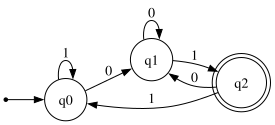

In [98]:
from automata.fa.dfa import DFA

# Defina o DFA aqui
dfa01 = DFA(
        states={'q0','q1','q2'},
        input_symbols={'0', '1'},
        transitions={
            'q0': {'0': 'q1', '1': 'q0'},
            'q1': {'1': 'q2', '0': 'q1'},
            'q2': {'1': 'q0', '0': 'q1'}
        },
        initial_state='q0',
        final_states={'q2'}
)

# Gerando a expressão regular
dfa01.show_diagram()

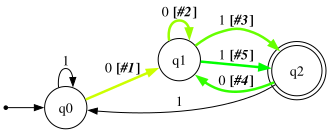

In [99]:
# Simulação
cadeia = '00101'
dfa01.show_diagram(cadeia)

### (02)

Construa um NFA que reconhece a linguagem sobre $\Sigma = \{a,b\}$, onde as cadeias são sequencias de $a$'s seguidas por sequencias de $b$'s ou sequências de $b$'s seguidas por sequencias de $a$'s.

São exemplos de cadeias aceitas: $aa, bb, abb, aabbb, baaa, \ldots$



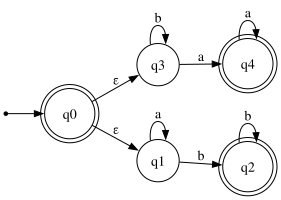

In [100]:
## cadeia comeca com sequencia de 0s seguida por sequencia de 1s ou vice-versa
from automata.fa.nfa import NFA

# Defina o NFA aqui
nfa01 = NFA(
        states={'q0','q1','q2','q3','q4'},
        input_symbols={'a', 'b'},
        transitions={
            'q0': {'': {'q1','q3'}},
            'q1': {'a': {'q1'}, 'b': {'q2'}, },
            'q3': {'b': {'q3'}, 'a': {'q4'}, },
            'q2': {'b': {'q2'},},
            'q4': {'a': {'q4'},},
        },
        initial_state='q0',
        final_states={'q2','q4','q0'}
)



# Gere e imprima a expressão regular aqui
nfa01.show_diagram()

Rastreamento de todos os estados alcançados:
δ({'q0', 'q3', 'q1'},b) -> {'q3', 'q2'}
δ({'q3', 'q2'},b) -> {'q3', 'q2'}
δ({'q3', 'q2'},a) -> {'q4'}
δ({'q4'},a) -> {'q4'}
δ({'q4'},a) -> {'q4'}
True
True


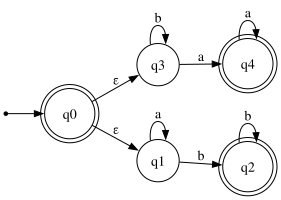

In [101]:
cadeia='bbaaa'
gen = nfa01.read_input_stepwise(cadeia)
print_rastreamento(gen,nfa01,cadeia)
print(nfa01.accepts_input(cadeia))
print(nfa01.accepts_input(''))
nfa01.show_diagram('')

### (3)
Construa um NFA equivalente ao DFA da questão (1) e um DFA equivalente ao NFA da questão (2)
> Dica: Utilize funções de conversão disponíveis em `automata-lib`

In [105]:
# Construa o NFA aqui
nfa2 = NFA.from_dfa(dfa01)
nfa2.accepts_input('01101')

True

In [104]:
# Construa o DFA aqui
dfa2 = DFA.from_nfa(nfa01).to_complete()
dfa2.accepts_input('bbbbbbaaaa')

True

### (4)

Construa uma expressão regular para cada uma das linguagens das questões (1) e (2) usando `re` de python.

In [106]:
import re
# Escreva o padrão para Questão (01)
pat1 = r"(0|1)*01"

# Testando
w1 = "001010101"
print("Casou" if not re.fullmatch(pat1,w1) is None else "Não casou")


Casou


In [107]:
import re
# Escreva o padrão para Questão (02)
pat2 = r"(a*b*)|(b*a*)"

# Testando
w2 = "aaaaaabbbbbbb"
print("Casou" if not re.fullmatch(pat2, w2) is None else "Não casou")

Casou


### (5)

Usando funções de `automata-lib`, gere uma expressão regular para cada uma das linguagens das questões (1) e (2) a partir dos FAs construídos nestas questões.

> **Dica**: Utilize GNFAs.

In [108]:
# Implemente a geração para (01) aqui
from automata.fa.gnfa import GNFA

g_pat1 = GNFA.from_dfa(dfa01).to_regex()
print(g_pat1)

1*0(111*0|(10|0))*1


In [109]:
# Implemente a geração para (02) aqui
g_pat2 = GNFA.from_nfa(nfa01).to_regex()
print(g_pat2)

b*aa*|(a*bb*)?


### (6)

Compare as expressões produzidas nas questões (4) e (5). É possível determinar se são equivalentes? Como isto poderia ser feito usando automata-lib?

In [96]:
# Implemente aqui o código para comparar as expressões
from automata.regex import regex

print(regex.isequal(g_pat1, pat1))
print(regex.isequal(g_pat2, g_pat2))


True
True


### (7)

O padrão antigo de placas de veículos no Brasil segue o formato:

LLLNNNN

onde:

* L é uma letra maiúscula de A a Z

* N é um dígito de 0 a 9

Exemplos válidos: ABC1234, XYZ0001

Exemplos inválidos: AB1234, ABCD123, 1234ABC, ABU1234, ABC12345

Construa um DFA usando `automata-lib` que reconheça cadeias exatamente nesse formato.

> **Dica**: Ao invés de enumerar detalhadamente o dicionário de transições para  cada símbolo de entrada, é possível construi-lo de forma programática e associa-lo a chave. Por exemplo:

    dict_q0 = {letra: 'q1' for letra in letras} | {d: 'err' for d in digitos}
    ...
    transitions = {
          'q0': dict_q0,



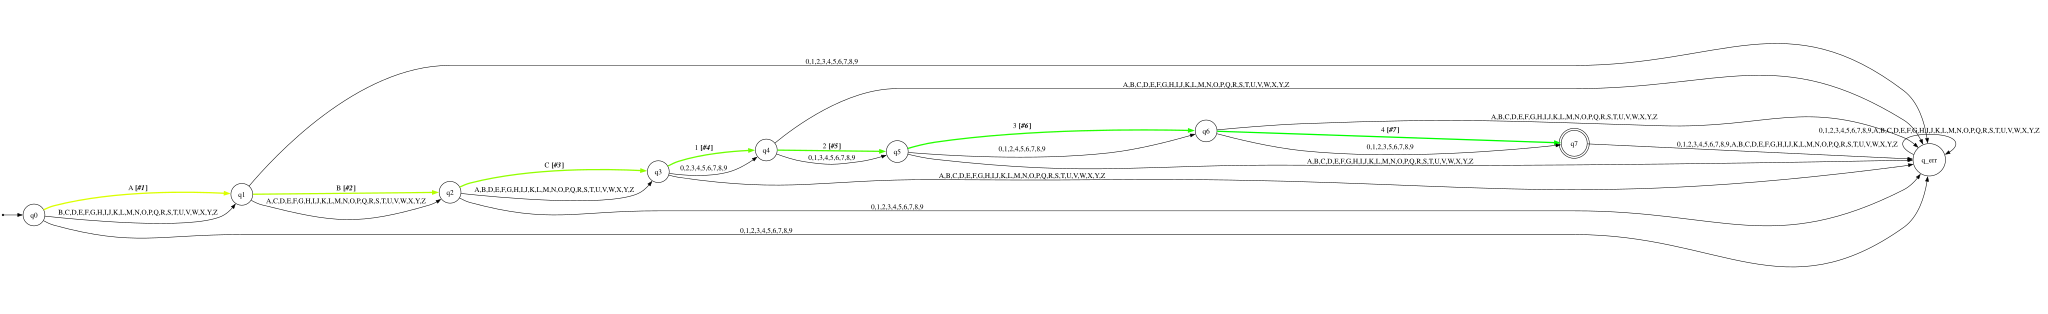

In [81]:
# Escreva aqui seu código
import string

letras = set(string.ascii_uppercase)
digitos = set(string.digits)

dict_q0 = {letra: 'q1' for letra in letras} | {d: 'q_err' for d in digitos}
dict_q1 = {letra: 'q2' for letra in letras} | {d: 'q_err' for d in digitos}
dict_q2 = {letra: 'q3' for letra in letras} | {d: 'q_err' for d in digitos}

dict_q3 = {d: 'q4' for d in digitos} | {l: 'q_err' for l in letras}
dict_q4 = {d: 'q5' for d in digitos} | {l: 'q_err' for l in letras}
dict_q5 = {d: 'q6' for d in digitos} | {l: 'q_err' for l in letras}
dict_q6 = {d: 'q7' for d in digitos} | {l: 'q_err' for l in letras}

# Construindo as transições
transitions = {
    'q0': dict_q0,
    'q1': dict_q1,
    'q2': dict_q2,
    'q3': dict_q3,
    'q4': dict_q4,
    'q5': dict_q5,
    'q6': dict_q6,
    'q7': {l: 'q_err' for l in letras} | {d: 'q_err' for d in digitos},
    'q_err': {l: 'q_err' for l in letras} | {d: 'q_err' for d in digitos},
}

dfa = DFA(
    states={'q0','q1','q2','q3','q4','q5','q6','q7','q_err'},
    input_symbols=letras.union(digitos),
    transitions=transitions,
    initial_state='q0',
    final_states={'q7'}
)

dfa.show_diagram('ABC1234')

In [85]:
# Testes
assert dfa.accepts_input('ABC1234') == True, "Deveria aceitar: ABC1234"
assert dfa.accepts_input('AB1234') == False, "Deveria rejeitar: AB1234"
assert dfa.accepts_input('XYZ0001') == True, "Deveria aceitar: XYZ0001"
assert dfa.accepts_input('A1B2C3D') == False, "Deveria rejeitar: A1B2C3D"
assert dfa.accepts_input('1234ABC') == False, "Deveria rejeitar: 1234ABC"
